In [1]:
import sys
sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torchvision import transforms

from src.model import build_model
from src.preprocessing import apply_clahe

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(num_classes=5)
model.load_state_dict(torch.load("../outputs/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded")

C:\Users\Dyuk\AppData\Local\Temp\ipykernel_21000\727690650.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../outputs/best_model.pth",

Model loaded


In [2]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        target_layer = model.layer4[-1]
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_backward_hook(self._save_gradients)
    
    def _save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, img_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(img_tensor)
        output[0, class_idx].backward()
        
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam = GradCAM(model)
print("GradCAM ready")

GradCAM ready


In [5]:
def visualize_gradcam(img_path, model, gradcam, df):
    img = apply_clahe(img_path)
    img_id = img_path.replace("\\", "/").split("/")[-1].replace(".png", "")
    true_label = df[df['id_code'] == img_id]['diagnosis'].values[0]
    
    transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])
    img_tensor = transform(Image.fromarray(img)).unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)
    
    with torch.set_grad_enabled(True):
        output = model(img_tensor)
        pred_label = output.argmax(1).item()
        cam = gradcam.generate(img_tensor, pred_label)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img + 0.5 * heatmap).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"Original | True: {true_label}")
    axes[0].axis("off")
    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay | Pred: {pred_label}")
    axes[2].axis("off")
    plt.tight_layout()
    plt.savefig(f"../outputs/gradcam_{img_id}.png", dpi=150, bbox_inches='tight')
    plt.show()


Grade 0:


c:\Users\Dyuk\anaconda3\envs\retina\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


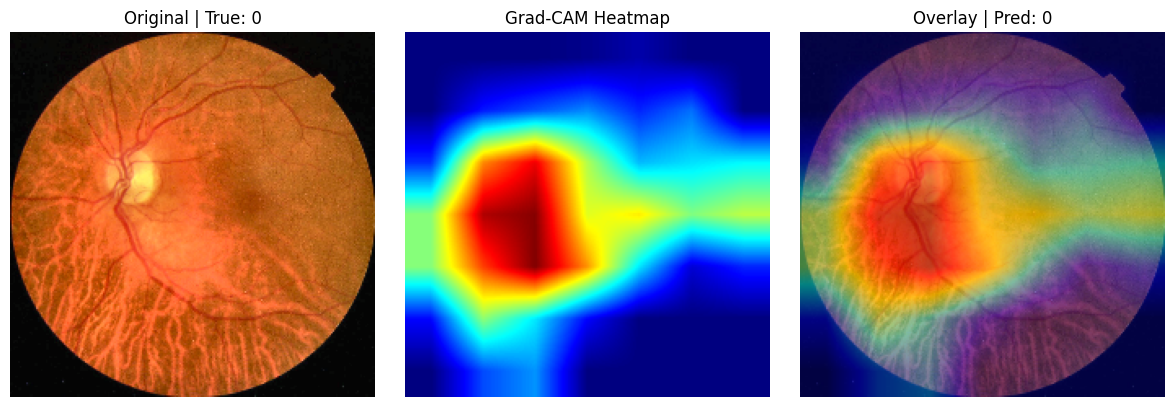


Grade 1:


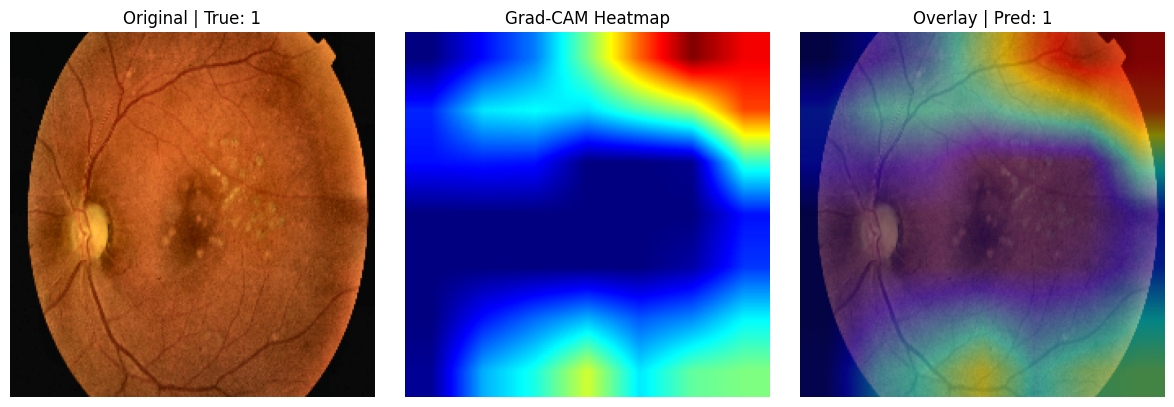


Grade 2:


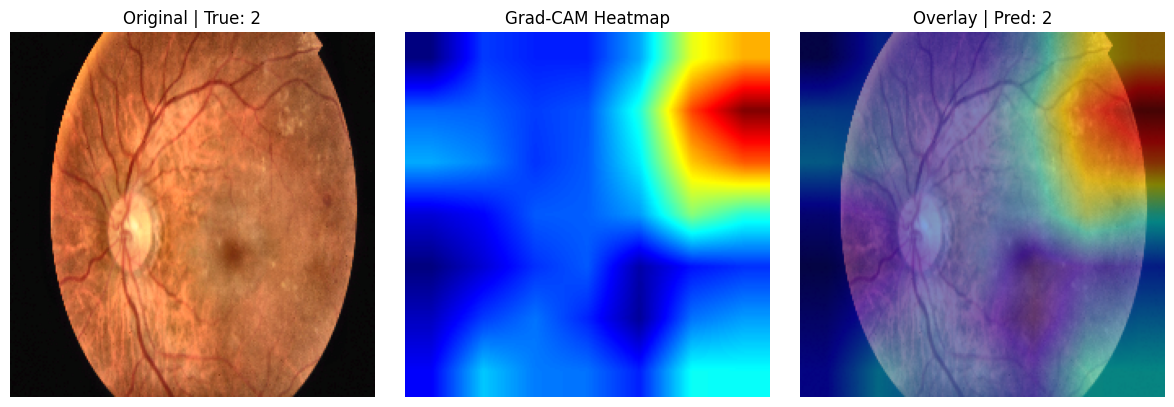


Grade 3:


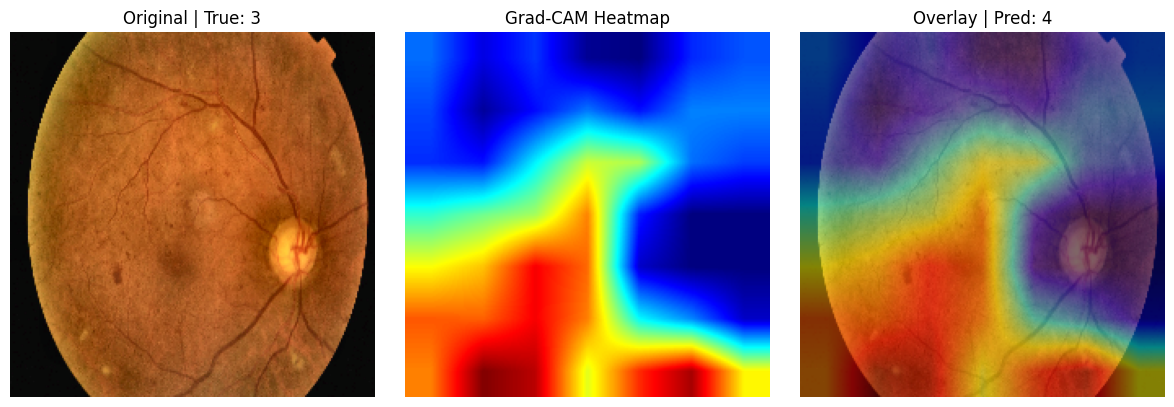


Grade 4:


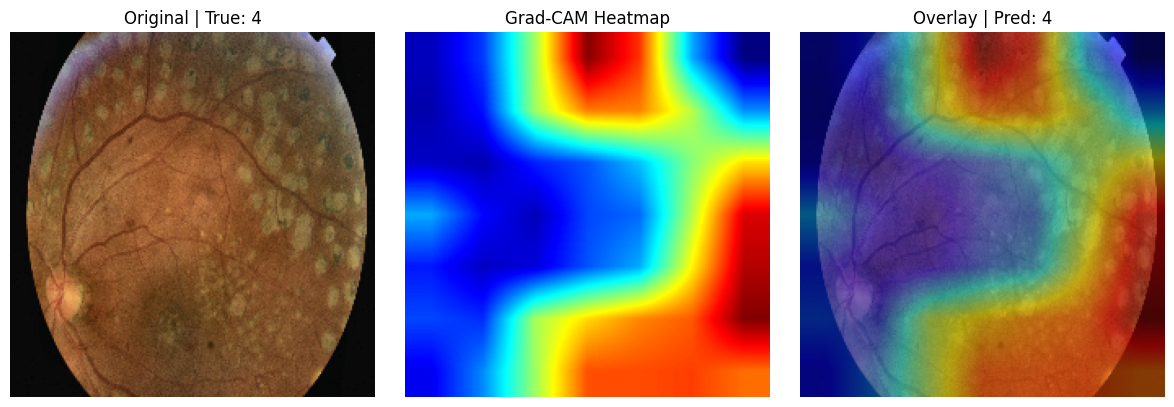

In [6]:
import pandas as pd

df = pd.read_csv("../data/aptos2019-blindness-detection/train.csv")
IMG_DIR = "../data/aptos2019-blindness-detection/train_images/"

for grade in range(5):
    sample = df[df['diagnosis'] == grade].sample(1, random_state=42)
    img_path = IMG_DIR + sample['id_code'].values[0] + ".png"
    print(f"\nGrade {grade}:")
    visualize_gradcam(img_path, model, gradcam, df)

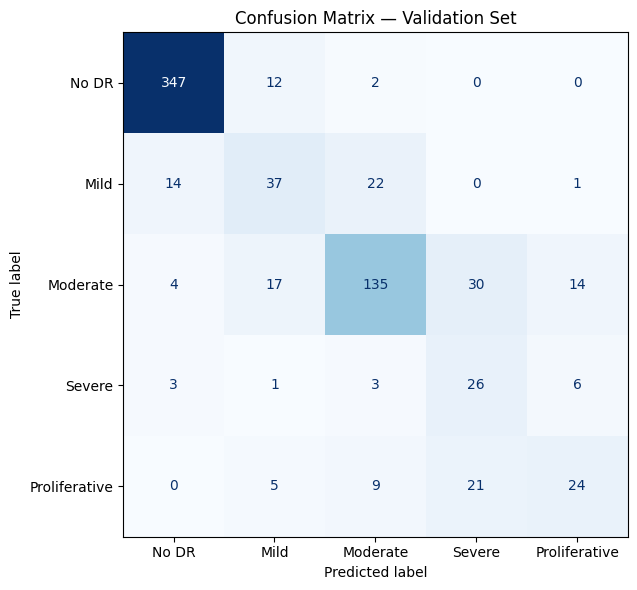

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from src.train import val_epoch
from torch.utils.data import DataLoader
from src.dataset import RetinalDataset
import pandas as pd

df = pd.read_csv("../data/aptos2019-blindness-detection/train.csv")
from sklearn.model_selection import train_test_split
_, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['diagnosis'])

val_dataset = RetinalDataset(val_df, "../data/aptos2019-blindness-detection/train_images", augment=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["No DR","Mild","Moderate","Severe","Proliferative"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix Analysis

- No DR detection: 96% accuracy - clinically safe (no false negatives for healthy class)
- Mistakes are localized to adjacent grades - model has learned severity ordering
- Mild class (50%) is hardest - visually closest to healthy eyes
- No cross-extreme confusions (0->4 or 4->0) observed
- Next step: focal loss or ordinal regression loss to better handle grade boundaries